<a href="https://colab.research.google.com/github/Mais-M/cisa-kev-sql-investigation/blob/main/cisa_kev_sql_investigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

url = "https://www.cisa.gov/sites/default/files/feeds/known_exploited_vulnerabilities.json"

df = pd.read_json(url)

df.head()

import requests
import pandas as pd

url = "https://www.cisa.gov/sites/default/files/feeds/known_exploited_vulnerabilities.json"

data = requests.get(url).json()

df = pd.DataFrame(data["vulnerabilities"])

print(df.shape)
df.head()

import requests
import pandas as pd

url = "https://www.cisa.gov/sites/default/files/feeds/known_exploited_vulnerabilities.json"

data = requests.get(url).json()

df = pd.DataFrame(data["vulnerabilities"])

print(df.shape)
df.head()

df.to_csv("cisa_kev.csv", index=False)
print("CSV created successfully")

(1662, 11)
(1662, 11)
CSV created successfully


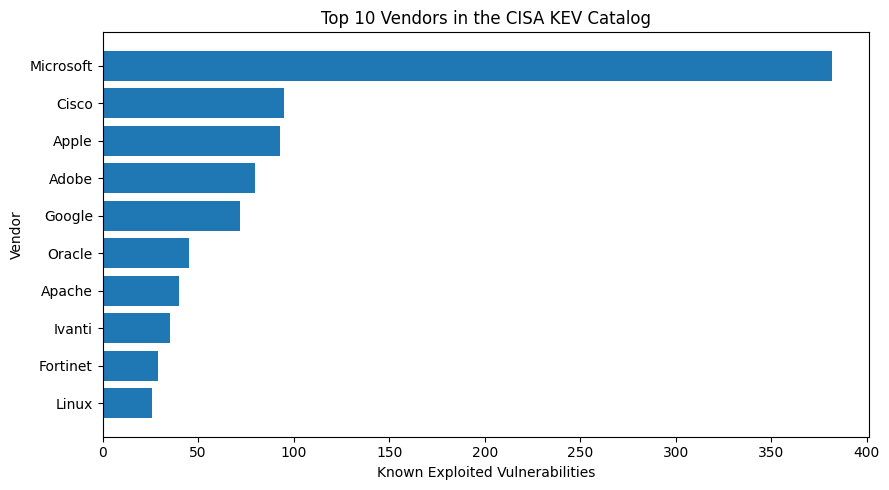

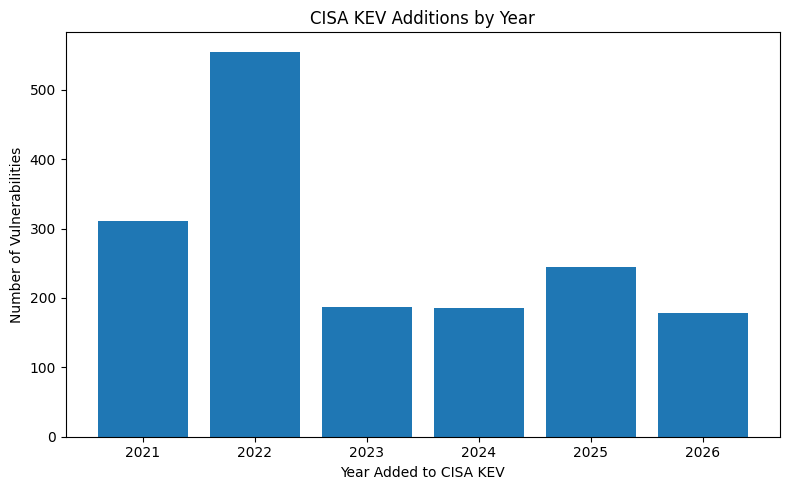

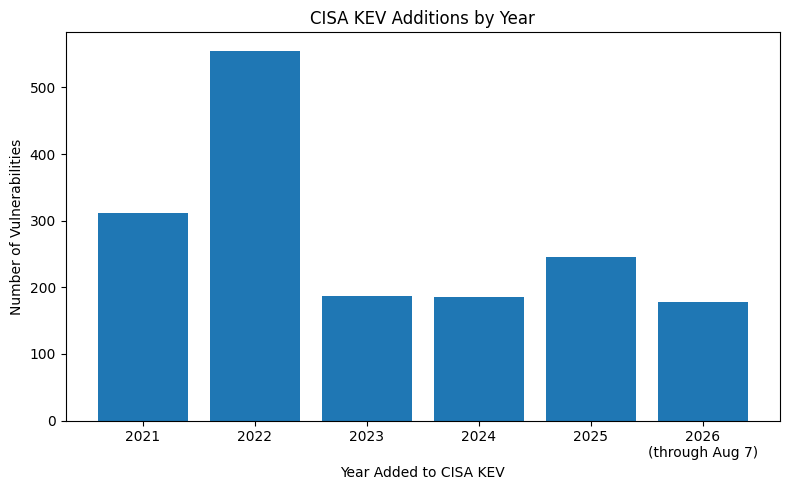

In [15]:
import duckdb

con = duckdb.connect()

con.execute("""
CREATE OR REPLACE TABLE kev AS
SELECT *
FROM read_csv_auto('cisa_kev.csv')
""")

con.execute("SELECT COUNT(*) FROM kev").fetchall()

con.execute("DESCRIBE kev").df()

con.execute("""
SELECT
    vendorProject,
    COUNT(*) AS vulnerability_count
FROM kev
GROUP BY vendorProject
ORDER BY vulnerability_count DESC
LIMIT 10
""").df()

con.execute("""
SELECT
    product,
    COUNT(*) AS vulnerability_count
FROM kev
GROUP BY product
ORDER BY vulnerability_count DESC
LIMIT 10
""").df()

con.execute("""
SELECT
    knownRansomwareCampaignUse,
    COUNT(*) AS vulnerability_count,
    ROUND(
        COUNT(*) * 100.0 / (SELECT COUNT(*) FROM kev),
        1
    ) AS percentage
FROM kev
GROUP BY knownRansomwareCampaignUse
ORDER BY vulnerability_count DESC
""").df()

con.execute("""
SELECT
    vendorProject,
    COUNT(*) AS ransomware_related_vulnerabilities
FROM kev
WHERE knownRansomwareCampaignUse = 'Known'
GROUP BY vendorProject
ORDER BY ransomware_related_vulnerabilities DESC
LIMIT 10
""").df()

con.execute("""
SELECT
    YEAR(CAST(dateAdded AS DATE)) AS year,
    COUNT(*) AS vulnerabilities_added
FROM kev
GROUP BY year
ORDER BY year
""").df()

import matplotlib.pyplot as plt

top_vendors = con.execute("""
SELECT
    vendorProject,
    COUNT(*) AS vulnerability_count
FROM kev
GROUP BY vendorProject
ORDER BY vulnerability_count DESC
LIMIT 10
""").df()

plt.figure(figsize=(9,5))
plt.barh(top_vendors["vendorProject"], top_vendors["vulnerability_count"])
plt.gca().invert_yaxis()
plt.xlabel("Known Exploited Vulnerabilities")
plt.ylabel("Vendor")
plt.title("Top 10 Vendors in the CISA KEV Catalog")
plt.tight_layout()

plt.savefig("top_vendors.png", dpi=300, bbox_inches="tight")
plt.show()

yearly = con.execute("""
SELECT
    YEAR(CAST(dateAdded AS DATE)) AS year,
    COUNT(*) AS vulnerabilities_added
FROM kev
GROUP BY year
ORDER BY year
""").df()

plt.figure(figsize=(8,5))
plt.bar(yearly["year"].astype(str), yearly["vulnerabilities_added"])
plt.xlabel("Year Added to CISA KEV")
plt.ylabel("Number of Vulnerabilities")
plt.title("CISA KEV Additions by Year")
plt.tight_layout()

plt.savefig("kev_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

yearly["year_label"] = yearly["year"].astype(str)
yearly.loc[yearly["year"] == 2026, "year_label"] = "2026\n(through Aug 7)"

plt.figure(figsize=(8,5))
plt.bar(yearly["year_label"], yearly["vulnerabilities_added"])
plt.xlabel("Year Added to CISA KEV")
plt.ylabel("Number of Vulnerabilities")
plt.title("CISA KEV Additions by Year")
plt.tight_layout()

plt.savefig("kev_by_year.png", dpi=300, bbox_inches="tight")
plt.show()